In [1]:
import os
import math
import warnings
#import radonCenter
import nmf_imaging
import numpy as np
import pandas as pd
import scipy.ndimage
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap,SymLogNorm
from multiprocess import Pool
from astropy import wcs
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy import convolution as conv
from astropy.visualization import astropy_mpl_style
from astropy.utils.exceptions import AstropyWarning
from pyklip.klip import rotate as pyklipRotate
from astropy.nddata import CCDData
import ccdproc
import webbpsf

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-062 CANNOT BE CHECKED AGAINST ONLINE VERSION


In [15]:
def loadncenter(filepath):
    
    sci = []
    err = []
    dq = []
    pa = []
    with fits.open(filepath) as hdul:
        prim = hdul[0].header
        scidat = hdul[1].header
        scii = hdul[1].data
        erri = hdul[2].data 
        dqi = hdul[3].data
        wcs0 = wcs.WCS(hdul[1].header, naxis=2)
        pa = scidat["ROLL_REF"]
        #rot_angle = np.rad2deg(math.atan2(wcs0.wcs.cd[1][0], wcs0.wcs.cd[0][0]))
        #pa = 180*np.sign(rot_angle) - rot_angle
        
    for i in scii:
        sci1 = Cutout2D(i, (scidat['CRPIX1'],scidat['CRPIX2']), (80,80))
        sci.append(sci1.data)
        
    for i in erri:
        err1 = Cutout2D(i, (scidat['CRPIX1'],scidat['CRPIX2']), (80,80))
        err.append(err1.data)
        
    for i in dqi:
        dq1 = Cutout2D(i, (scidat['CRPIX1'],scidat['CRPIX2']), (80,80))
        dq.append(dq1.data)
        
    """for i in scii:
        sci12 = pyklipRotate(i, pa, (scidat['CRPIX1'],scidat['CRPIX2']), astr_hdr=wcs0)
        sci1 = Cutout2D(sci12, (scidat['CRPIX1'],scidat['CRPIX2']), (80,80))
        sci.append(sci1.data)
        
    for i in erri:
        err12 = pyklipRotate(i, pa, (scidat['CRPIX1'],scidat['CRPIX2']), astr_hdr=wcs0)
        err1 = Cutout2D(err12, (scidat['CRPIX1'],scidat['CRPIX2']), (80,80))
        err.append(err1.data)"""
        
    #sci = np.array(np.nan_to_num(sci, nan=5))
    #err = np.array(np.nan_to_num(err, nan=5))
    #dq = np.array(np.nan_to_num(dq, nan=5))
    
    sci = np.array(sci)
    err = np.array(err)
    dq = np.array(dq)
    
    """nsci = np.zeros(sci.shape)
    nerr = np.zeros(err.shape)
    
    for i in range(len(sci)):
        j = pyklipRotate(sci[i], pa, [40,40], astr_hdr=wcs0)
        k = pyklipRotate(err[i], pa, [40,40], astr_hdr=wcs0)
        nsci[i] = j
        nerr[i] = k"""
        
    #sci = sci/scidat["XPOSURE"]
    #err = err/scidat["XPOSURE"]
    
    for x in range(len(dq)):
    
        dq10 = np.isnan(sci[x])
        dq01 = np.invert(dq10)
        medsci = scipy.ndimage.median_filter(np.nan_to_num(sci[x], nan=np.nanmean(sci[x])),size=3)
        multsciadd = np.multiply(dq10,medsci)
        multscisub = np.multiply(dq01,np.nan_to_num(sci[x]))
        sci[x] = np.add(multscisub,multsciadd)
        mederr = scipy.ndimage.median_filter(np.nan_to_num(err[x], nan=np.nanmean(err[x])),size=3)
        multerradd = np.multiply(dq10,mederr)
        multerrsub = np.multiply(dq01,np.nan_to_num(err[x]))
        err[x] = np.add(multerrsub,multerradd)
        
    return prim, scidat, sci, err, dq, wcs0, pa

In [16]:
#Eps Indi 1550
warnings.filterwarnings('ignore')
#path = '/Users/saikrishanth/spaceKLIP_new/examples/MIRI_sky_2243/spaceklip/bgsub/'
path = '/Users/saikrishanth/Desktop/OneDrive - University of Arizona/MIRI/eps_indi/stage2/'

primt, scidatt, scit, errt, dqt, wcst0, pat = loadncenter(path+'jw02243007001_04101_00001_mirimage_calints.fits')

primr0, scidatr0, scir0, errr0, dqr0, wcsr0, par0 = loadncenter(path+'jw02243006001_04101_00001_mirimage_calints.fits')
primr1, scidatr1, scir1, errr1, dqr1, wcsr1, par1 = loadncenter(path+'jw02243006001_04101_00002_mirimage_calints.fits')
primr2, scidatr2, scir2, errr2, dqr2, wcsr2, par2 = loadncenter(path+'jw02243006001_04101_00003_mirimage_calints.fits')
primr3, scidatr3, scir3, errr3, dqr3, wcsr3, par3 = loadncenter(path+'jw02243006001_04101_00004_mirimage_calints.fits')
primr4, scidatr4, scir4, errr4, dqr4, wcsr4, par4 = loadncenter(path+'jw02243006001_04101_00005_mirimage_calints.fits')

primr = np.concatenate((primr0,primr1,primr2,primr3,primr4))
scidatr = np.concatenate((scidatr0,scidatr1,scidatr2,scidatr3,scidatr4))
scir = np.concatenate((scir0,scir1,scir2,scir3,scir4))
errr = np.concatenate((errr0,errr1,errr2,errr3,errr4))
dqr = np.concatenate((dqr0,dqr1,dqr2,dqr3,dqr4))
par = par0
wcsr = wcsr0

In [287]:
# Eps Indi 1065
warnings.filterwarnings('ignore')
path = '/Users/saikrishanth/spaceKLIP_new/examples/MIRI_sky_2243/spaceklip/bgsub/'

primt, scidatt, scit, errt, dqt, wcst0, pat = loadncenter(path+'jw02243008001_04101_00001_mirimage_calints.fits')

primr0, scidatr0, scir0, errr0, dqr0, wcsr0, par0 = loadncenter(path+'jw02243005001_04101_00001_mirimage_calints.fits')
primr1, scidatr1, scir1, errr1, dqr1, wcsr1, par1 = loadncenter(path+'jw02243005001_04101_00002_mirimage_calints.fits')
primr2, scidatr2, scir2, errr2, dqr2, wcsr2, par2 = loadncenter(path+'jw02243005001_04101_00003_mirimage_calints.fits')
primr3, scidatr3, scir3, errr3, dqr3, wcsr3, par3 = loadncenter(path+'jw02243005001_04101_00004_mirimage_calints.fits')
primr4, scidatr4, scir4, errr4, dqr4, wcsr4, par4 = loadncenter(path+'jw02243005001_04101_00005_mirimage_calints.fits')

primr = np.concatenate((primr0,primr1,primr2,primr3,primr4))
scidatr = np.concatenate((scidatr0,scidatr1,scidatr2,scidatr3,scidatr4))
scir = np.concatenate((scir0,scir1,scir2,scir3,scir4))
errr = np.concatenate((errr0,errr1,errr2,errr3,errr4))
dqr = np.concatenate((dqr0,dqr1,dqr2,dqr3,dqr4))
par = par0
wcsr = wcsr0

In [18]:
%%time
components = nmf_imaging.NMFcomponents(scir, ref_err = errr, n_components = 90, maxiters = 1e4, oneByOne=True)

Building components one by one...
	1 of 70
Current Chi2=0.0943, Previous Chi2=6.1430, Change=98.4648% @ niters=0
Took 0.000 minutes to reach current solution.
	2 of 70
Current Chi2=0.0605, Previous Chi2=0.0609, Change=0.7613% @ niters=0
Current Chi2=0.0527, Previous Chi2=0.0532, Change=0.9820% @ niters=20
Current Chi2=0.0496, Previous Chi2=0.0496, Change=0.0304% @ niters=40
Current Chi2=0.0494, Previous Chi2=0.0494, Change=0.0123% @ niters=60
Current Chi2=0.0493, Previous Chi2=0.0493, Change=0.0055% @ niters=80
Current Chi2=0.0493, Previous Chi2=0.0493, Change=0.0031% @ niters=100
Current Chi2=0.0493, Previous Chi2=0.0493, Change=0.0014% @ niters=120
Took 0.009 minutes to reach current solution.
	3 of 70
Current Chi2=0.0493, Previous Chi2=0.0496, Change=0.6705% @ niters=0
Current Chi2=0.0478, Previous Chi2=0.0479, Change=0.2138% @ niters=20
Current Chi2=0.0458, Previous Chi2=0.0459, Change=0.1788% @ niters=40
Current Chi2=0.0448, Previous Chi2=0.0449, Change=0.0654% @ niters=60
Current

Current Chi2=0.0190, Previous Chi2=0.0190, Change=0.0050% @ niters=2100
Current Chi2=0.0190, Previous Chi2=0.0190, Change=0.0048% @ niters=2120
Current Chi2=0.0190, Previous Chi2=0.0190, Change=0.0050% @ niters=2140
Current Chi2=0.0190, Previous Chi2=0.0190, Change=0.0048% @ niters=2160
Current Chi2=0.0189, Previous Chi2=0.0189, Change=0.0043% @ niters=2180
Current Chi2=0.0189, Previous Chi2=0.0189, Change=0.0037% @ niters=2200
Current Chi2=0.0189, Previous Chi2=0.0189, Change=0.0031% @ niters=2220
Current Chi2=0.0189, Previous Chi2=0.0189, Change=0.0029% @ niters=2240
Current Chi2=0.0189, Previous Chi2=0.0189, Change=0.0031% @ niters=2260
Current Chi2=0.0189, Previous Chi2=0.0189, Change=0.0036% @ niters=2280
Current Chi2=0.0189, Previous Chi2=0.0189, Change=0.0039% @ niters=2300
Current Chi2=0.0188, Previous Chi2=0.0188, Change=0.0034% @ niters=2320
Current Chi2=0.0188, Previous Chi2=0.0188, Change=0.0030% @ niters=2340
Current Chi2=0.0188, Previous Chi2=0.0188, Change=0.0030% @ nite

Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0024% @ niters=760
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0024% @ niters=780
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0023% @ niters=800
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0021% @ niters=820
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0019% @ niters=840
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0018% @ niters=860
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0018% @ niters=880
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0019% @ niters=900
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0021% @ niters=920
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0023% @ niters=940
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0025% @ niters=960
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0025% @ niters=980
Current Chi2=0.0151, Previous Chi2=0.0151, Change=0.0028% @ niters=1000
Current Chi2=0.0150, Previous Chi2=0.0150, Change=0.0032% @ niters=1020
Curr

Current Chi2=0.0136, Previous Chi2=0.0136, Change=0.0034% @ niters=3040
Current Chi2=0.0136, Previous Chi2=0.0136, Change=0.0081% @ niters=3060
Current Chi2=0.0136, Previous Chi2=0.0136, Change=0.0026% @ niters=3080
Current Chi2=0.0136, Previous Chi2=0.0136, Change=0.0020% @ niters=3100
Current Chi2=0.0136, Previous Chi2=0.0136, Change=0.0023% @ niters=3120
Current Chi2=0.0135, Previous Chi2=0.0135, Change=0.0027% @ niters=3140
Current Chi2=0.0135, Previous Chi2=0.0135, Change=0.0025% @ niters=3160
Current Chi2=0.0135, Previous Chi2=0.0135, Change=0.0020% @ niters=3180
Current Chi2=0.0135, Previous Chi2=0.0135, Change=0.0017% @ niters=3200
Current Chi2=0.0135, Previous Chi2=0.0135, Change=0.0016% @ niters=3220
Current Chi2=0.0135, Previous Chi2=0.0135, Change=0.0019% @ niters=3240
Current Chi2=0.0135, Previous Chi2=0.0135, Change=0.0048% @ niters=3260
Current Chi2=0.0135, Previous Chi2=0.0135, Change=0.0057% @ niters=3280
Current Chi2=0.0135, Previous Chi2=0.0135, Change=0.0023% @ nite

Current Chi2=0.0103, Previous Chi2=0.0103, Change=0.0072% @ niters=1260
Current Chi2=0.0102, Previous Chi2=0.0102, Change=0.0071% @ niters=1280
Current Chi2=0.0102, Previous Chi2=0.0102, Change=0.0069% @ niters=1300
Current Chi2=0.0102, Previous Chi2=0.0102, Change=0.0068% @ niters=1320
Current Chi2=0.0102, Previous Chi2=0.0102, Change=0.0069% @ niters=1340
Current Chi2=0.0102, Previous Chi2=0.0102, Change=0.0070% @ niters=1360
Current Chi2=0.0102, Previous Chi2=0.0102, Change=0.0072% @ niters=1380
Current Chi2=0.0102, Previous Chi2=0.0102, Change=0.0071% @ niters=1400
Current Chi2=0.0101, Previous Chi2=0.0101, Change=0.0068% @ niters=1420
Current Chi2=0.0101, Previous Chi2=0.0101, Change=0.0065% @ niters=1440
Current Chi2=0.0101, Previous Chi2=0.0101, Change=0.0063% @ niters=1460
Current Chi2=0.0101, Previous Chi2=0.0101, Change=0.0062% @ niters=1480
Current Chi2=0.0101, Previous Chi2=0.0101, Change=0.0061% @ niters=1500
Current Chi2=0.0101, Previous Chi2=0.0101, Change=0.0061% @ nite

...

Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0014% @ niters=9000
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0014% @ niters=9020
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0014% @ niters=9040
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0014% @ niters=9060
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0014% @ niters=9080
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0014% @ niters=9100
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0014% @ niters=9120
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0014% @ niters=9140
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0013% @ niters=9160
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0013% @ niters=9180
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0013% @ niters=9200
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0013% @ niters=9220
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0013% @ niters=9240
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0013% @ nite

Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0024% @ niters=1260
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1280
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1300
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1320
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1340
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1360
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1380
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1400
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1420
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1440
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1460
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1480
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=1500
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ nite

Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0076% @ niters=3540
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0076% @ niters=3560
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0077% @ niters=3580
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0077% @ niters=3600
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0077% @ niters=3620
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0078% @ niters=3640
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0078% @ niters=3660
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0079% @ niters=3680
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0079% @ niters=3700
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0079% @ niters=3720
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0080% @ niters=3740
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0080% @ niters=3760
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0080% @ niters=3780
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0080% @ nite

Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0053% @ niters=5820
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0053% @ niters=5840
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0052% @ niters=5860
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0052% @ niters=5880
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0051% @ niters=5900
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0051% @ niters=5920
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0051% @ niters=5940
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0050% @ niters=5960
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0050% @ niters=5980
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0050% @ niters=6000
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0049% @ niters=6020
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0049% @ niters=6040
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0049% @ niters=6060
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0048% @ nite

Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0024% @ niters=8100
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0024% @ niters=8120
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0024% @ niters=8140
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=8160
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=8180
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=8200
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=8220
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=8240
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=8260
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0023% @ niters=8280
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0022% @ niters=8300
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0022% @ niters=8320
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0022% @ niters=8340
Current Chi2=0.0000, Previous Chi2=0.0000, Change=0.0022% @ nite

In [20]:
results = np.zeros(scit.shape) 

for i in range(scit.shape[0]):
    print(f"Number {i+1} of {scit.shape[0]}")
    trg = scit[i]
    trg_err = errt[i]
    #mask = tjwstnans[i]
    model = nmf_imaging.NMFmodelling(trg = trg, trg_err = trg_err, components = components, maxiters = 1e4, n_components = 70)
    result = nmf_imaging.NMFsubtraction(trg, model) 
    results[i] = result

Number 1 of 14
Current Chi2=0.4062, Previous Chi2=6.2142, Change=93.4636% @ niters=0
Current Chi2=0.1732, Previous Chi2=0.1769, Change=2.1305% @ niters=20
Current Chi2=0.1505, Previous Chi2=0.1508, Change=0.1835% @ niters=40
Current Chi2=0.1471, Previous Chi2=0.1472, Change=0.0839% @ niters=60
Current Chi2=0.1450, Previous Chi2=0.1451, Change=0.0621% @ niters=80
Current Chi2=0.1435, Previous Chi2=0.1435, Change=0.0493% @ niters=100
Current Chi2=0.1422, Previous Chi2=0.1422, Change=0.0403% @ niters=120
Current Chi2=0.1411, Previous Chi2=0.1412, Change=0.0336% @ niters=140
Current Chi2=0.1403, Previous Chi2=0.1403, Change=0.0286% @ niters=160
Current Chi2=0.1395, Previous Chi2=0.1396, Change=0.0246% @ niters=180
Current Chi2=0.1389, Previous Chi2=0.1389, Change=0.0214% @ niters=200
Current Chi2=0.1384, Previous Chi2=0.1384, Change=0.0188% @ niters=220
Current Chi2=0.1379, Previous Chi2=0.1379, Change=0.0166% @ niters=240
Current Chi2=0.1374, Previous Chi2=0.1375, Change=0.0148% @ niters=

Current Chi2=0.1454, Previous Chi2=0.1455, Change=0.0606% @ niters=260
Current Chi2=0.1437, Previous Chi2=0.1438, Change=0.0556% @ niters=280
Current Chi2=0.1422, Previous Chi2=0.1423, Change=0.0498% @ niters=300
Current Chi2=0.1409, Previous Chi2=0.1410, Change=0.0437% @ niters=320
Current Chi2=0.1398, Previous Chi2=0.1398, Change=0.0377% @ niters=340
Current Chi2=0.1388, Previous Chi2=0.1389, Change=0.0322% @ niters=360
Current Chi2=0.1380, Previous Chi2=0.1380, Change=0.0273% @ niters=380
Current Chi2=0.1373, Previous Chi2=0.1373, Change=0.0232% @ niters=400
Current Chi2=0.1367, Previous Chi2=0.1367, Change=0.0197% @ niters=420
Current Chi2=0.1362, Previous Chi2=0.1362, Change=0.0169% @ niters=440
Current Chi2=0.1358, Previous Chi2=0.1358, Change=0.0145% @ niters=460
Current Chi2=0.1354, Previous Chi2=0.1354, Change=0.0126% @ niters=480
Current Chi2=0.1351, Previous Chi2=0.1351, Change=0.0111% @ niters=500
Current Chi2=0.1348, Previous Chi2=0.1348, Change=0.0098% @ niters=520
Curren

Number 5 of 14
Current Chi2=0.4907, Previous Chi2=6.2289, Change=92.1219% @ niters=0
Current Chi2=0.2140, Previous Chi2=0.2206, Change=3.0163% @ niters=20
Current Chi2=0.1696, Previous Chi2=0.1703, Change=0.3690% @ niters=40
Current Chi2=0.1622, Previous Chi2=0.1624, Change=0.1549% @ niters=60
Current Chi2=0.1583, Previous Chi2=0.1585, Change=0.0949% @ niters=80
Current Chi2=0.1559, Previous Chi2=0.1560, Change=0.0661% @ niters=100
Current Chi2=0.1541, Previous Chi2=0.1542, Change=0.0504% @ niters=120
Current Chi2=0.1527, Previous Chi2=0.1528, Change=0.0406% @ niters=140
Current Chi2=0.1516, Previous Chi2=0.1517, Change=0.0340% @ niters=160
Current Chi2=0.1507, Previous Chi2=0.1507, Change=0.0290% @ niters=180
Current Chi2=0.1499, Previous Chi2=0.1499, Change=0.0250% @ niters=200
Current Chi2=0.1492, Previous Chi2=0.1492, Change=0.0218% @ niters=220
Current Chi2=0.1486, Previous Chi2=0.1486, Change=0.0191% @ niters=240
Current Chi2=0.1480, Previous Chi2=0.1481, Change=0.0167% @ niters=

Current Chi2=0.1348, Previous Chi2=0.1348, Change=0.0015% @ niters=1000
Current Chi2=0.1348, Previous Chi2=0.1348, Change=0.0015% @ niters=1020
Current Chi2=0.1347, Previous Chi2=0.1347, Change=0.0014% @ niters=1040
Current Chi2=0.1347, Previous Chi2=0.1347, Change=0.0013% @ niters=1060
Current Chi2=0.1347, Previous Chi2=0.1347, Change=0.0013% @ niters=1080
Current Chi2=0.1346, Previous Chi2=0.1346, Change=0.0012% @ niters=1100
Current Chi2=0.1346, Previous Chi2=0.1346, Change=0.0011% @ niters=1120
Current Chi2=0.1346, Previous Chi2=0.1346, Change=0.0011% @ niters=1140
Current Chi2=0.1345, Previous Chi2=0.1345, Change=0.0010% @ niters=1160
Current Chi2=0.1345, Previous Chi2=0.1345, Change=0.0010% @ niters=1180
Took 0.008 minutes to reach current solution.
Number 8 of 14
Current Chi2=0.4892, Previous Chi2=6.2189, Change=92.1333% @ niters=0
Current Chi2=0.2137, Previous Chi2=0.2201, Change=2.9201% @ niters=20
Current Chi2=0.1693, Previous Chi2=0.1701, Change=0.4476% @ niters=40
Current C

Current Chi2=0.1034, Previous Chi2=0.1034, Change=0.0013% @ niters=1020
Current Chi2=0.1034, Previous Chi2=0.1034, Change=0.0013% @ niters=1040
Current Chi2=0.1033, Previous Chi2=0.1033, Change=0.0012% @ niters=1060
Current Chi2=0.1033, Previous Chi2=0.1033, Change=0.0012% @ niters=1080
Current Chi2=0.1033, Previous Chi2=0.1033, Change=0.0011% @ niters=1100
Current Chi2=0.1033, Previous Chi2=0.1033, Change=0.0011% @ niters=1120
Current Chi2=0.1033, Previous Chi2=0.1033, Change=0.0010% @ niters=1140
Took 0.006 minutes to reach current solution.
Number 10 of 14
Current Chi2=0.4306, Previous Chi2=6.2184, Change=93.0752% @ niters=0
Current Chi2=0.1610, Previous Chi2=0.1670, Change=3.5876% @ niters=20
Current Chi2=0.1243, Previous Chi2=0.1247, Change=0.3005% @ niters=40
Current Chi2=0.1203, Previous Chi2=0.1204, Change=0.1173% @ niters=60
Current Chi2=0.1179, Previous Chi2=0.1180, Change=0.0914% @ niters=80
Current Chi2=0.1159, Previous Chi2=0.1160, Change=0.0765% @ niters=100
Current Chi2=

Current Chi2=0.1191, Previous Chi2=0.1191, Change=0.0029% @ niters=920
Current Chi2=0.1190, Previous Chi2=0.1190, Change=0.0027% @ niters=940
Current Chi2=0.1189, Previous Chi2=0.1190, Change=0.0026% @ niters=960
Current Chi2=0.1189, Previous Chi2=0.1189, Change=0.0025% @ niters=980
Current Chi2=0.1188, Previous Chi2=0.1188, Change=0.0023% @ niters=1000
Current Chi2=0.1188, Previous Chi2=0.1188, Change=0.0022% @ niters=1020
Current Chi2=0.1187, Previous Chi2=0.1187, Change=0.0021% @ niters=1040
Current Chi2=0.1187, Previous Chi2=0.1187, Change=0.0019% @ niters=1060
Current Chi2=0.1186, Previous Chi2=0.1186, Change=0.0018% @ niters=1080
Current Chi2=0.1186, Previous Chi2=0.1186, Change=0.0017% @ niters=1100
Current Chi2=0.1186, Previous Chi2=0.1186, Change=0.0016% @ niters=1120
Current Chi2=0.1185, Previous Chi2=0.1185, Change=0.0016% @ niters=1140
Current Chi2=0.1185, Previous Chi2=0.1185, Change=0.0015% @ niters=1160
Current Chi2=0.1184, Previous Chi2=0.1184, Change=0.0014% @ niters=1

Current Chi2=0.1625, Previous Chi2=0.1625, Change=0.0015% @ niters=820
Current Chi2=0.1624, Previous Chi2=0.1624, Change=0.0014% @ niters=840
Current Chi2=0.1624, Previous Chi2=0.1624, Change=0.0013% @ niters=860
Current Chi2=0.1624, Previous Chi2=0.1624, Change=0.0012% @ niters=880
Current Chi2=0.1623, Previous Chi2=0.1623, Change=0.0011% @ niters=900
Current Chi2=0.1623, Previous Chi2=0.1623, Change=0.0011% @ niters=920
Current Chi2=0.1622, Previous Chi2=0.1622, Change=0.0010% @ niters=940
Took 0.005 minutes to reach current solution.
Number 14 of 14
Current Chi2=0.3907, Previous Chi2=6.2222, Change=93.7209% @ niters=0
Current Chi2=0.1587, Previous Chi2=0.1616, Change=1.8083% @ niters=20
Current Chi2=0.1424, Previous Chi2=0.1425, Change=0.1374% @ niters=40
Current Chi2=0.1397, Previous Chi2=0.1398, Change=0.0748% @ niters=60
Current Chi2=0.1379, Previous Chi2=0.1380, Change=0.0592% @ niters=80
Current Chi2=0.1364, Previous Chi2=0.1365, Change=0.0484% @ niters=100
Current Chi2=0.1352,

In [ ]:
nresults = []

for i in results:
    rotationcenter = (i.shape[1]/2, i.shape[0]/2)
    q = pyklipRotate(i, pat, rotationcenter, astr_hdr=wcst0)
    nresults.append(q)
    
for i in results[168:336]:
    rotationcenter = (i.shape[1]/2, i.shape[0]/2)
    q = pyklipRotate(i, pat1, rotationcenter, astr_hdr=wcst1)
    nresults.append(q)
    
"""cresults = []
for i in nresults:
    clip = stats.sigma_clip(i, sigma=3, maxiters=5, stdfunc='mad_std')
    cresults.append(clip)"""
    
rlist = []
for i in results:
    q = CCDData(i, unit='adu')
    rlist.append(q)
    
c = ccdproc.combine(rlist, method='median')
c1140 = c.data

In [300]:
subtracted=nresults

sub_std_frm=np.nanstd(np.nanstd(subtracted,axis=2),axis=1)

sub_ordered=sub_std_frm.copy()
sub_ordered.sort()

#cutoff=sub_ordered[int(round(len(sub_ordered)*.7))] #counts, %
cutoff=5

print(cutoff)

good_frames=np.where(sub_std_frm<cutoff)[0]

gresults = [nresults[i] for i in good_frames]

5


In [208]:
bad_frames=np.where(sub_std_frm>cutoff)[0]

In [78]:
results0 = np.zeros(scit0.shape)
results1 = np.zeros(scit1.shape)

for i in range(len(results[0:40])):
    results0[i] = results[i]
    
for i in range(len(results[40:80])):
    results1[i] = results[40+i] 

In [79]:
nresults = []
for i in results0:
    rotationcenter = (i.shape[1]/2, i.shape[0]/2)
    q = pyklipRotate(i, pat0, rotationcenter)
    nresults.append(q)
    
for i in results1:
    rotationcenter = (i.shape[1]/2, i.shape[0]/2)
    q = pyklipRotate(i, pat1, rotationcenter)
    nresults.append(q)

In [80]:
rlist = []
for i in nresults:
    q = CCDData(i, unit='adu')
    rlist.append(q)

In [81]:
c = ccdproc.combine(rlist, method='median')
c1140 = c.data

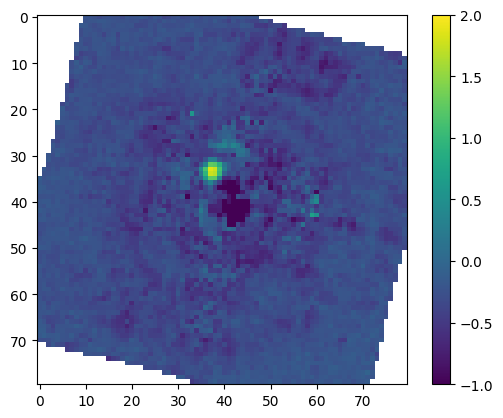

In [83]:
plt.imshow(c1140, vmax=2, vmin=-1)
plt.colorbar()

In [8]:
rlist = []
for i in results:
    q = CCDData(i, unit='adu')
    rlist.append(q)

In [11]:
c = ccdproc.combine(rlist, method='average')
c1140 = c.data

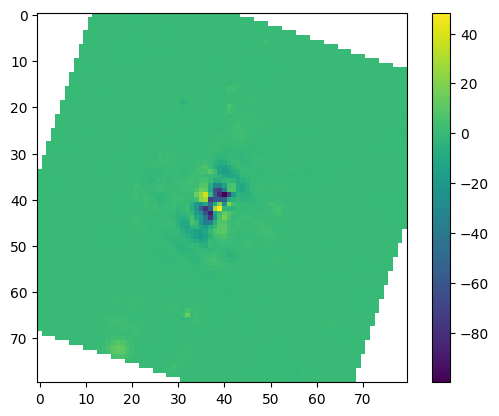

In [44]:
plt.imshow(c1140)
plt.colorbar()

In [ ]:
PIXELSCL=0.065*u.arcsecond
hdu = fits.PrimaryHDU(c1140)
hdu.header["PIXELSCL"]=PIXELSCL.value

In [115]:
from astropy.units import Unit as u
from synphot import SpectralElement
from synphot import Observation
import astropy
mJy = astropy.units.def_unit('mJy', 0.001 * astropy.units.Jansky)

In [65]:
def zeros_to_nan_profile(profile):
    profile[1][np.where(profile[1]==0)]=np.nan
    return profile

def radial_profile(hdulist_or_filename=None, ext=0, ee=False, center=None, stddev=False, mad=False, binsize=None, 
                   maxradius=None, normalize='None', pa_range=None, slice=0):
    
    if isinstance(hdulist_or_filename, str):
        hdu_list = fits.open(hdulist_or_filename)
    elif isinstance(hdulist_or_filename, fits.HDUList):
        hdu_list = hdulist_or_filename
    else:
        raise ValueError("input must be a filename or HDUlist")

    if hdu_list[ext].header['NAXIS'] == 3:
        # data cube, so pick out just one slice
        image = hdu_list[ext].data[slice].copy()  # don't change normalization of actual input array, work with a copy!
    else:
        image = hdu_list[ext].data.copy()  # don't change normalization of actual input array, work with a copy!

    if normalize.lower() == 'peak':
        _log.debug("Calculating profile with PSF normalized to peak = 1")
        image /= image.max()
    elif normalize.lower() == 'total':
        _log.debug("Calculating profile with PSF normalized to total = 1")
        image /= image.sum()

    pixelscale = hdu_list[ext].header['PIXELSCL']

    if binsize is None:
        binsize = pixelscale

    y, x = np.indices(image.shape, dtype=float)
    if center is None:
        # get exact center of image
        # center = (image.shape[1]/2, image.shape[0]/2)
        center = tuple((a - 1) / 2.0 for a in image.shape[::-1])

    x -= center[0]
    y -= center[1]

    r = np.sqrt(x ** 2 + y ** 2) * pixelscale / binsize  # radius in bin size steps

    if pa_range is None:
        # Use full image
        ind = np.argsort(r.flat)
        sr = r.flat[ind]  # sorted r
        sim = image.flat[ind]  # sorted image

    else:
        # Apply the PA range restriction
        pa = np.rad2deg(np.arctan2(-x, y))  # Note the (-x,y) convention is needed for astronomical PA convention
        mask = (pa >= pa_range[0]) & (pa <= pa_range[1])
        ind = np.argsort(r[mask].flat)
        sr = r[mask].flat[ind]
        sim = image[mask].flat[ind]

    ri = sr.astype(int)  # sorted r as int
    deltar = ri[1:] - ri[:-1]  # assume all radii represented (more work if not)
    rind = np.where(deltar)[0]
    nr = rind[1:] - rind[:-1]  # number in radius bin
    csim = np.nan_to_num(sim).cumsum(dtype=float)  # cumulative sum to figure out sums for each bin
    # np.nancumsum is implemented in >1.12
    tbin = csim[rind[1:]] - csim[rind[:-1]]  # sum for image values in radius bins
    radialprofile = tbin / nr

    # pre-pend the initial element that the above code misses.
    radialprofile2 = np.empty(len(radialprofile) + 1)
    if rind[0] != 0:
        radialprofile2[0] = csim[rind[0]] / (
                rind[0] + 1)  # if there are multiple elements in the center bin, average them
    else:
        radialprofile2[0] = csim[0]  # otherwise if there's just one then just take it.
    radialprofile2[1:] = radialprofile
    
    rr = np.arange(ri.min(), ri.min() + len(
        radialprofile2)) * binsize + binsize * 0.5  # these should be centered in the bins, so add a half.

    if maxradius is not None:
        crop = rr < maxradius
        rr = rr[crop]
        radialprofile2 = radialprofile2[crop]

    if stddev:
        stddevs = np.zeros_like(radialprofile2)
        r_pix = r * binsize
        for i, radius in enumerate(rr):
            if i == 0:
                wg = np.where(r < radius + binsize / 2)
            else:
                wg = np.where((r_pix >= (radius - binsize / 2)) & (r_pix < (radius + binsize / 2)))
                # wg = np.where( (r >= rr[i-1]) &  (r <rr[i] )))
            stddevs[i] = np.nanstd(image[wg])
        return rr, stddevs
    
    if mad:
        mads = np.zeros_like(radialprofile2)
        r_pix = r * binsize
        for i, radius in enumerate(rr):
            if i == 0:
                wg = np.where(r < radius + binsize / 2)
            else:
                wg = np.where((r_pix >= (radius - binsize / 2)) & (r_pix < (radius + binsize / 2)))
            mads[i] = np.nanmedian(np.absolute(image[wg]-np.nanmedian(image[wg])))
        return rr, mads

    if not ee:
        return rr, radialprofile2
    else:
        ee = csim[rind]
        return rr, radialprofile2, ee

In [144]:
PHOTMJSR=    1.846868872642517 #/ Flux density (MJy/steradian) producing 1 cps   
PHOTUJA2=    43.40960113184807 #/ Flux density (uJy/arcsec2) producing 1 cps     
PIXAR_SR= 2.84403609523084E-13 #/ Nominal pixel area in steradians               
PIXAR_A2=               0.0121 #/ Nominal pixel area in arcsec^2        

In [233]:
cttomjy = (PIXAR_SR)*1e+6

In [43]:
PIXELSCL=0.11*u.arcsecond
hdu = fits.PrimaryHDU(c1140*mask*PHOTMJSR*PIXAR_SR)
hdu.header["PIXELSCL"]=PIXELSCL.value
nmf_50 = fits.HDUList(hdus=hdu)
nmf_50_mad = zeros_to_nan_profile(radial_profile(nmf_50,mad=True))*u.count

In [68]:
import astropy.units as u

In [73]:
PIXELSCL=0.11*u.arcsecond
hdu = fits.PrimaryHDU(klip1065*klipmask1065)
hdu.header["PIXELSCL"]=PIXELSCL.value
klip_1065 = fits.HDUList(hdus=hdu)
klip_1065_mad = zeros_to_nan_profile(radial_profile(klip_1065,stddev=True))*u.count

In [74]:
PIXELSCL=0.11*u.arcsecond
hdu = fits.PrimaryHDU(the1550*mask1550)
hdu.header["PIXELSCL"]=PIXELSCL.value
nmf_1550 = fits.HDUList(hdus=hdu)
nmf_1550_mad = zeros_to_nan_profile(radial_profile(nmf_1550,stddev=True))*u.count

/opt/anaconda3/envs/np_veclib/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [75]:
PIXELSCL=0.11*u.arcsecond
hdu = fits.PrimaryHDU(the1065*mask1065)
hdu.header["PIXELSCL"]=PIXELSCL.value
nmf_1065 = fits.HDUList(hdus=hdu)
nmf_1065_mad = zeros_to_nan_profile(radial_profile(nmf_1065,stddev=True))*u.count

In [76]:
#gain = 4*u.electron/u.count
#counts_bright_pixel1 = 2772.28*u.electron/gain/u.second
#counts_bright_pixel1550 = 30434.35*u.electron/gain/u.second
#counts_bright_pixel1065 = 82573.87*u.electron/gain/u.second
counts_bright_pixel1550 = 2240.0938401515386 #in MJy/sr
counts_bright_pixel1065 = 2240.0938401515386 #in MJy/sr

Text(0, 0.5, '5$\\sigma$ Contrast per pixel')

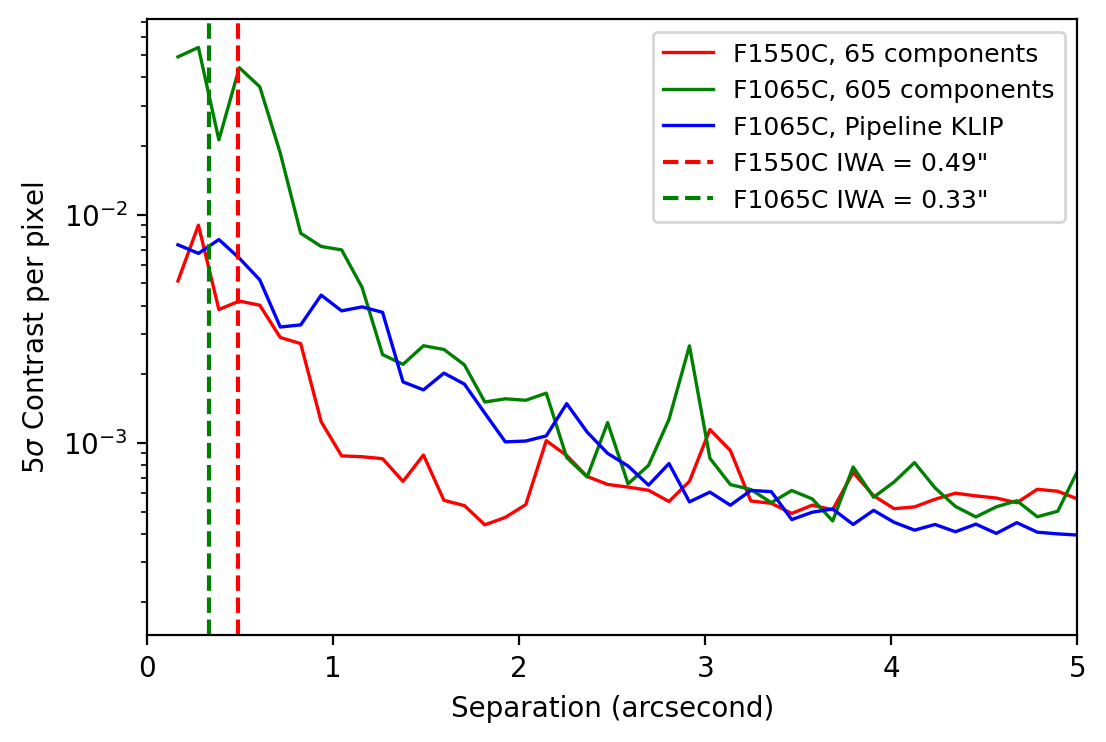

In [77]:
plt.figure(figsize=[6,4],dpi=200)

ax=plt.subplot(111)

ax.plot(nmf_1550_mad[0],5*nmf_1550_mad[1]/counts_bright_pixel1550,'-',label='F1550C, 65 components',color="red",linewidth=1.2)
ax.plot(nmf_1065_mad[0],5*nmf_1065_mad[1]/counts_bright_pixel1065,'-',label='F1065C, 605 components',color="green",linewidth=1.2)
ax.plot(klip_1065_mad[0],5*klip_1065_mad[1]/counts_bright_pixel1065,'-',label='F1065C, Pipeline KLIP',color="blue",linewidth=1.2)

ax.set_yscale('log')
#ax.set_xscale('log')

plt.xlim(0,5)
plt.axvline(0.49, c = 'red', ls = '--', label='F1550C IWA = 0.49\"')
plt.axvline(0.33, c = 'green', ls = '--', label='F1065C IWA = 0.33\"')
plt.legend(loc="upper right",fontsize=9)

plt.xlabel("Separation (arcsecond)")
plt.ylabel("5$\sigma$ Contrast per pixel")
#plt.ylabel("MAD Contrast")

In [244]:
from scipy.ndimage import gaussian_filter
from scipy import signal
from matplotlib.colors import SymLogNorm

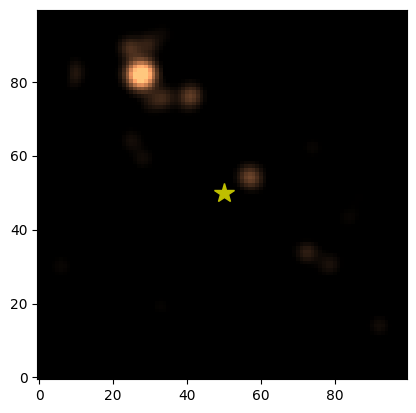

In [292]:
fig, ax = plt.subplots()
plt.imshow(finim, norm=SymLogNorm(1, 5, vmin=0.01, vmax=0.5), origin = 'lower', cmap='copper')
ax.plot(50,50,'*', ms=15, color='y')
#ax.plot(82,27,'ro')
#ax.add_patch(c)

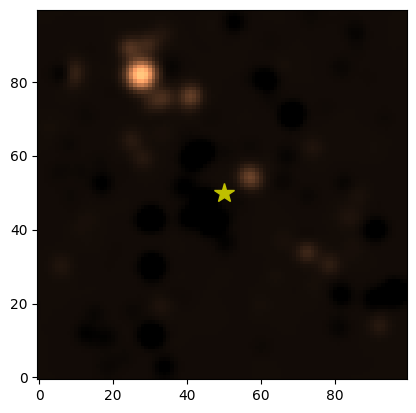

In [296]:
fig, ax = plt.subplots()
plt.imshow(finim, vmin=-0.04, vmax=0.6, origin = 'lower', cmap='copper')
ax.plot(50,50,'*', ms=15, color='y')
#ax.plot(82,27,'ro')
#ax.add_patch(c)